=== APLIKASI OPTIMASI RUTE DISTRIBUSI BARANG ===


Masukkan jumlah gudang (node):  5



Masukkan jarak antar gudang (isi 0 jika tidak ada jalur)


Jarak dari gudang 0 ke gudang 1:  12
Jarak dari gudang 0 ke gudang 2:  31
Jarak dari gudang 0 ke gudang 3:  56
Jarak dari gudang 0 ke gudang 4:  45
Jarak dari gudang 1 ke gudang 2:  12
Jarak dari gudang 1 ke gudang 3:  3
Jarak dari gudang 1 ke gudang 4:  12
Jarak dari gudang 2 ke gudang 3:  12
Jarak dari gudang 2 ke gudang 4:  15
Jarak dari gudang 3 ke gudang 4:  13



Representasi Graf (Adjacency List):
Gudang 0:
  -> Gudang 1 (jarak: 12)
  -> Gudang 2 (jarak: 31)
  -> Gudang 3 (jarak: 56)
  -> Gudang 4 (jarak: 45)
Gudang 1:
  -> Gudang 0 (jarak: 12)
  -> Gudang 2 (jarak: 12)
  -> Gudang 3 (jarak: 3)
  -> Gudang 4 (jarak: 12)
Gudang 2:
  -> Gudang 0 (jarak: 31)
  -> Gudang 1 (jarak: 12)
  -> Gudang 3 (jarak: 12)
  -> Gudang 4 (jarak: 15)
Gudang 3:
  -> Gudang 0 (jarak: 56)
  -> Gudang 1 (jarak: 3)
  -> Gudang 2 (jarak: 12)
  -> Gudang 4 (jarak: 13)
Gudang 4:
  -> Gudang 0 (jarak: 45)
  -> Gudang 1 (jarak: 12)
  -> Gudang 2 (jarak: 15)
  -> Gudang 3 (jarak: 13)


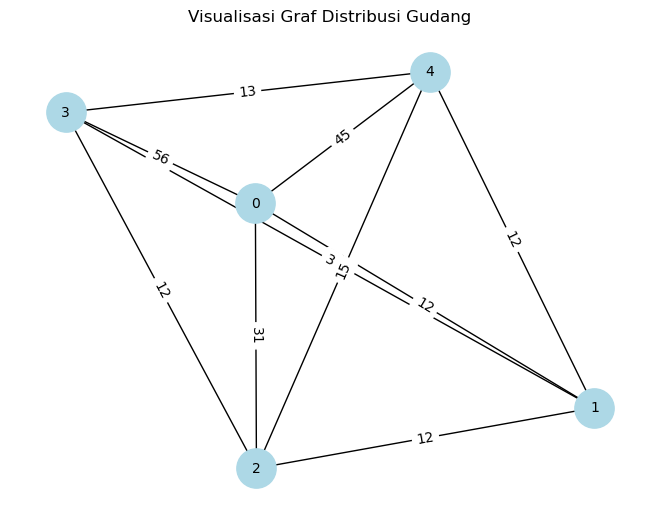


Menghitung rute terpendek dari gudang pusat (0)...

Hasil Dijkstra Iteratif:
Gudang 0 : 0
Gudang 1 : 12
Gudang 2 : 24
Gudang 3 : 15
Gudang 4 : 24

Hasil Dijkstra Rekursif:
Gudang 0 : 0
Gudang 1 : 12
Gudang 2 : 24
Gudang 3 : 15
Gudang 4 : 24

Waktu Eksekusi:
Iteratif  : 0.000036 detik
Rekursif : 0.000023 detik


In [14]:
import heapq
import time

# =========================
# INPUT GRAF DARI USER
# =========================
def input_graph():
    n = int(input("Masukkan jumlah gudang (node): "))
    graph = {}

    for i in range(n):
        graph[i] = {}

    print("\nMasukkan jarak antar gudang (isi 0 jika tidak ada jalur)")
    for i in range(n):
        for j in range(i + 1, n):
            w = int(input(f"Jarak dari gudang {i} ke gudang {j}: "))
            if w > 0:
                graph[i][j] = w
                graph[j][i] = w

    return graph


# =========================
# DIJKSTRA ITERATIF
# =========================
def dijkstra_iterative(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0

    pq = [(0, start)]

    while pq:
        current_dist, current_node = heapq.heappop(pq)

        if current_dist > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node].items():
            new_dist = current_dist + weight
            if new_dist < distances[neighbor]:
                distances[neighbor] = new_dist
                heapq.heappush(pq, (new_dist, neighbor))

    return distances


# =========================
# DIJKSTRA REKURSIF
# =========================
def dijkstra_recursive(graph, distances, visited, current):
    visited.add(current)

    for neighbor, weight in graph[current].items():
        if neighbor not in visited:
            new_dist = distances[current] + weight
            if new_dist < distances[neighbor]:
                distances[neighbor] = new_dist

    min_node = None
    min_dist = float('inf')

    for node in graph:
        if node not in visited and distances[node] < min_dist:
            min_dist = distances[node]
            min_node = node

    if min_node is not None:
        dijkstra_recursive(graph, distances, visited, min_node)


def run_dijkstra_recursive(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    visited = set()

    dijkstra_recursive(graph, distances, visited, start)
    return distances
    
# =========================
# PRINT GRAPH
# =========================
def print_graph(graph):
    print("\nRepresentasi Graf (Adjacency List):")
    for node in graph:
        print(f"Gudang {node}:")
        for neighbor, weight in graph[node].items():
            print(f"  -> Gudang {neighbor} (jarak: {weight})")

import networkx as nx
import matplotlib.pyplot as plt

# =========================
# DRAW GRAPH
# =========================

def draw_graph(graph):
    G = nx.Graph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G, pos,
        with_labels=True,
        node_color='lightblue',
        node_size=800,
        font_size=10
    )

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("Visualisasi Graf Distribusi Gudang")
    plt.show()
# =========================
# MAIN APLIKASI
# =========================
def main():
    print("=== APLIKASI OPTIMASI RUTE DISTRIBUSI BARANG ===")

    graph = input_graph()
    start_node = 0
    print_graph(graph)
    draw_graph(graph)

    print("\nMenghitung rute terpendek dari gudang pusat (0)...")

    start = time.time()
    result_iter = dijkstra_iterative(graph, start_node)
    time_iter = time.time() - start

    start = time.time()
    result_rec = run_dijkstra_recursive(graph, start_node)
    time_rec = time.time() - start

    print("\nHasil Dijkstra Iteratif:")
    for node, dist in result_iter.items():
        print(f"Gudang {node} : {dist}")

    print("\nHasil Dijkstra Rekursif:")
    for node, dist in result_rec.items():
        print(f"Gudang {node} : {dist}")

    print("\nWaktu Eksekusi:")
    print(f"Iteratif  : {time_iter:.6f} detik")
    print(f"Rekursif : {time_rec:.6f} detik")
    

# =========================
# RUN
# =========================
if __name__ == "__main__":
    main()
